
Con  riferimento  al  data  set  dell’esercitazione  su  clustering,  eseguire  una  classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 

Procedere  allo  split  train-test  secondo  il  rapporto  95%-15%  in  forma  stratificata 
secondo i valori della variabile target. 

2.Eseguire  l’imputazione  dei  dati  mancanti  con  le  stesse  strategie  dell’esercitazione 
precedente. 

3.Rimuovere  le  feature  che  presentano  elevata  correlazione  con  la  variabile  target  e 
successivamente analizzare le possibili feature multicollineari rimanenti. 

4.Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

5.Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest

In [17]:
import pandas as pd 
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset_esercitazione.csv')

df = df.drop(columns=['death','aps'])

X = df.drop(columns=['dzgroup'])
y = df.dzgroup


X_tr , X_te, y_tr, y_te = train_test_split(X,y, test_size=0.15, random_state=42, stratify=df['dzgroup'])



nan_percentage = X_tr.isna().sum() / X_tr.shape[0] * 100

print(nan_percentage )

col_to_delete = nan_percentage[nan_percentage > 15].index
X_tr = X_tr.drop(columns= col_to_delete)
X_te = X_te.drop(columns= col_to_delete)

print(X_tr.shape)
print(X_te.shape)

age          0.000000
sex          0.000000
dzclass      0.000000
num.co       0.000000
edu         17.741310
income      32.743248
scoma        0.012922
charges      1.899470
totcst       9.768704
totmcst     38.299522
avtisst      0.982039
race         0.465176
sps          0.012922
surv2m       0.012922
surv6m       0.012922
hday         0.000000
diabetes     0.000000
dementia     0.000000
ca           0.000000
prg2m       18.193565
prg6m       17.999742
dnr          0.335961
dnrday       0.335961
meanbp       0.012922
wblc         2.416333
hrt          0.012922
resp         0.012922
temp         0.012922
pafi        25.636387
alb         36.981522
bili        28.866779
crea         0.762372
sod          0.012922
ph          25.132446
glucose     49.592971
bun         47.939010
urine       53.301460
adlp        62.049360
adls        31.476935
adlsc        0.000000
dtype: float64
(7739, 26)
(1366, 26)


In [18]:
from sklearn.impute import SimpleImputer


imputer1 = SimpleImputer(strategy='median').set_output(transform='pandas')
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform='pandas')

num_feature = X_tr.select_dtypes(include=['number']).columns.tolist()
cat_feature = X_tr.select_dtypes( exclude=['number']).columns.tolist()


X_tr[num_feature] = imputer1.fit_transform(X_tr[num_feature])
X_tr[cat_feature] = imputer2.fit_transform(X_tr[cat_feature])


X_te[num_feature] = imputer1.transform(X_te[num_feature]) 
X_te[cat_feature] = imputer2.transform(X_te[cat_feature])


In [20]:
from sklearn.preprocessing import OrdinalEncoder


encoder1 = OrdinalEncoder().set_output(transform='pandas')

X_tr[cat_feature] = encoder1.fit_transform(X_tr[cat_feature] )
X_te[cat_feature] = encoder1.transform(X_te[cat_feature] )

from sklearn.preprocessing import LabelEncoder

encoder2 = LabelEncoder()

y_tr = encoder2.fit_transform( y_tr )

y_te = encoder2.fit_transform( y_te )



In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tr[num_feature] = scaler.fit_transform( X_tr[num_feature] )
X_te[num_feature] = scaler.transform( X_te[num_feature] )
print(X_tr.shape)
print(X_te.shape)

(7739, 26)
(1366, 26)


In [22]:
corr_matrix = X_tr.corr().abs()

threshold = 0.7

num_columns = len(X_tr.columns)

for i in range(num_columns):
    for j in range( i+1, num_columns):
        
        valore_corr = corr_matrix.iloc[i,j]
        
        if valore_corr > threshold:
            column_to_delete = corr_matrix.columns[j]
            X_tr = X_tr.drop(columns=[column_to_delete])
            X_te = X_te.drop(columns=[column_to_delete])
            
            print('Elimino colonna: ', column_to_delete )

Elimino colonna:  totcst
Elimino colonna:  surv2m
Elimino colonna:  surv6m


In [23]:
print(X_tr.shape)
print(X_te.shape)

(7739, 23)
(1366, 23)


In [24]:
from sklearn.feature_selection import SelectKBest, f_classif

select = SelectKBest(f_classif, k=18)

X_tr = select.fit_transform( X_tr , y_tr)
X_te = select.transform( X_te )



/home/lorenzopatti/Programmazione/Big Data/big-data/lib64/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [25]:
print(X_tr.shape)
print(X_te.shape)

(7739, 18)
(1366, 18)


[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]]
Migliori parametri trovati: {'criterion': 'log_loss', 'max_features': 5, 'min_samples_split': 10}
[[9.80666667e-01 9.50000000e-03 7.16666667e-03 ... 0.00000000e+00
  0.00000000e+00 2.66666667e-03]
 [1.88571429e-02 3.66460068e-01 5.29694555e-01 ... 0.00000000e+00
  8.33333333e-04 0.00000000e+00]
 [9.80972234e-01 1.76470588e-03 0.00000000e+00 ... 5.88235294e-04
  0.00000000e+00 1.66748252e-02]
 ...
 [1.18750000e-02 0.00000000e+00 4.04761905e-03 ... 9.63601190e-01
  1.42857143e-03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 4.44444444e-03
  4.34041551e-01 3.33333333e-03]
 [1.85714286e-02 3.96282051e-02 8.55932401e-02 ... 8.36028555e-01
  1.06250000e-02 1.42857143e-03]]


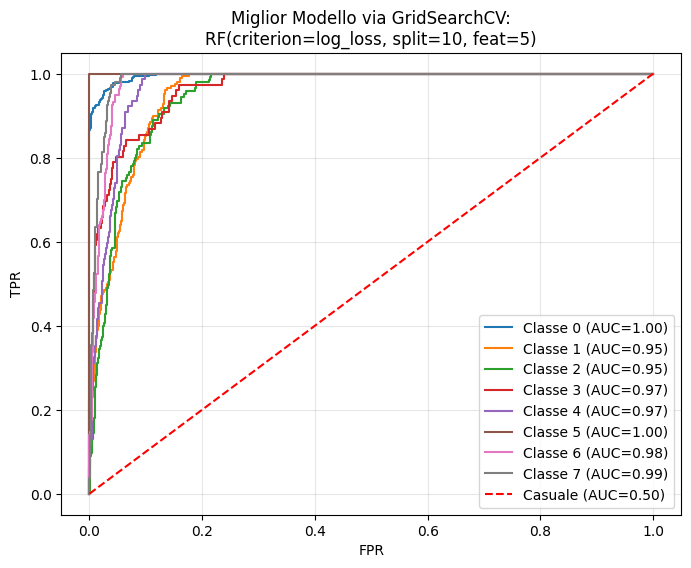

In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. Prepariamo le strutture per il multiclasse One-vs-Rest
classi = sorted(list(set(y_tr)))
y_test_binarized = label_binarize(y_te, classes=classi)

print(y_test_binarized)

# 2. Definiamo la griglia come un DIZIONARIO (lo vuole GridSearchCV)
param_grid = {
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 5]
}

# 3. Inizializziamo il modello base e la GridSearch
# Nota: usiamo 'roc_auc_ovr_weighted' o 'roc_auc_ovr' come scoring per il multiclasse
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    #scoring='roc_auc_ovr', 
    scoring='roc_auc_ovr_weighted'

)

# 4. Eseguiamo la ricerca (fa tutto da sola: cicli, fit e cross-validation)
grid_search.fit(X_tr, y_tr)

# 5. Estraiamo il vincitore e i suoi parametri 
best_classifier = grid_search.best_estimator_
best_params = grid_search.best_params_
best_params_name = f"RF(criterion={best_params['criterion']}, split={best_params['min_samples_split']}, feat={best_params['max_features']})"

print(f"Migliori parametri trovati: {best_params}")
# ==========================================
# FASE PLOT (Solo per il modello migliore estratto)
# ==========================================
plt.figure(figsize=(8, 6))

# Usiamo il miglior modello estratto per fare le previsioni sul test set
y_best_score = best_classifier.predict_proba(X_te)
print(y_best_score)

# Ciclo classico sulle classi per disegnare le curve ROC
for idx, classe in enumerate(classi):
    y_reale_classe = y_test_binarized[:, idx]
    y_score_classe = y_best_score[:, idx]
    
    auc_cl = roc_auc_score(y_reale_classe, y_score_classe)
    fpr, tpr, _ = roc_curve(y_reale_classe, y_score_classe)
    
    plt.plot(fpr, tpr, label=f"Classe {classe} (AUC={auc_cl:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Casuale (AUC=0.50)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f"Miglior Modello via GridSearchCV:\n{best_params_name}")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
print( y_test_binarized.sum(axis=0) )

[527 208 145  76  77  90 136 107]


In [ ]:
from torch.utils.data import Dataset
import torchnn as utils
import numpy as np
#trasformare dataframe in tensori

def MyDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.Tensor(X, dtype=torch.float32)
        
        self.X = self.X.unsqueeze(1)
        
        self.y = self.y.Tensor(y,dtype=torch.long)
        
    def __len__(self):
        # Dice a PyTorch quanti record ci sono nel dataset
        return len(self.X)
    
    def __getitem__(self,idx):
        
        return self.X[idx], self.y[idx]
    
    train_loader, val_loader, test_loader = utils.make_dataloaders(
        MyDataset(np.array(X_tr),np.array(y_tr))
        MyDataset(np.array(X_val),np.array(y_val))
        MyDataset(np.array(X_te),np.array(y_te))
    )